In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# EDA

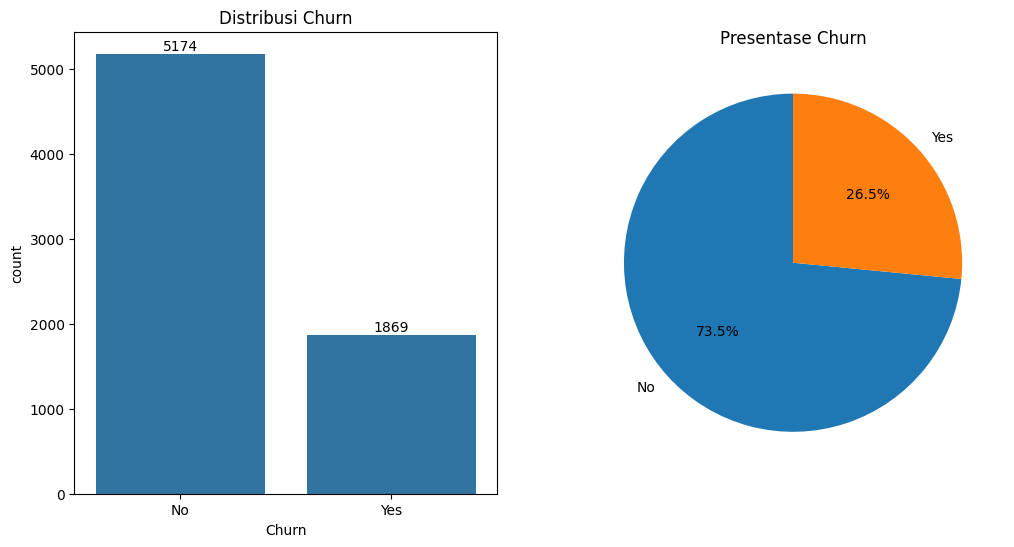

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Distribusi Churn dan presentasenya 
ax = sns.countplot(data=df, x='Churn', ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Distribusi Churn')

count_churn = df['Churn'].value_counts()
axes[1].pie(count_churn, labels=count_churn.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Presentase Churn')

plt.show()

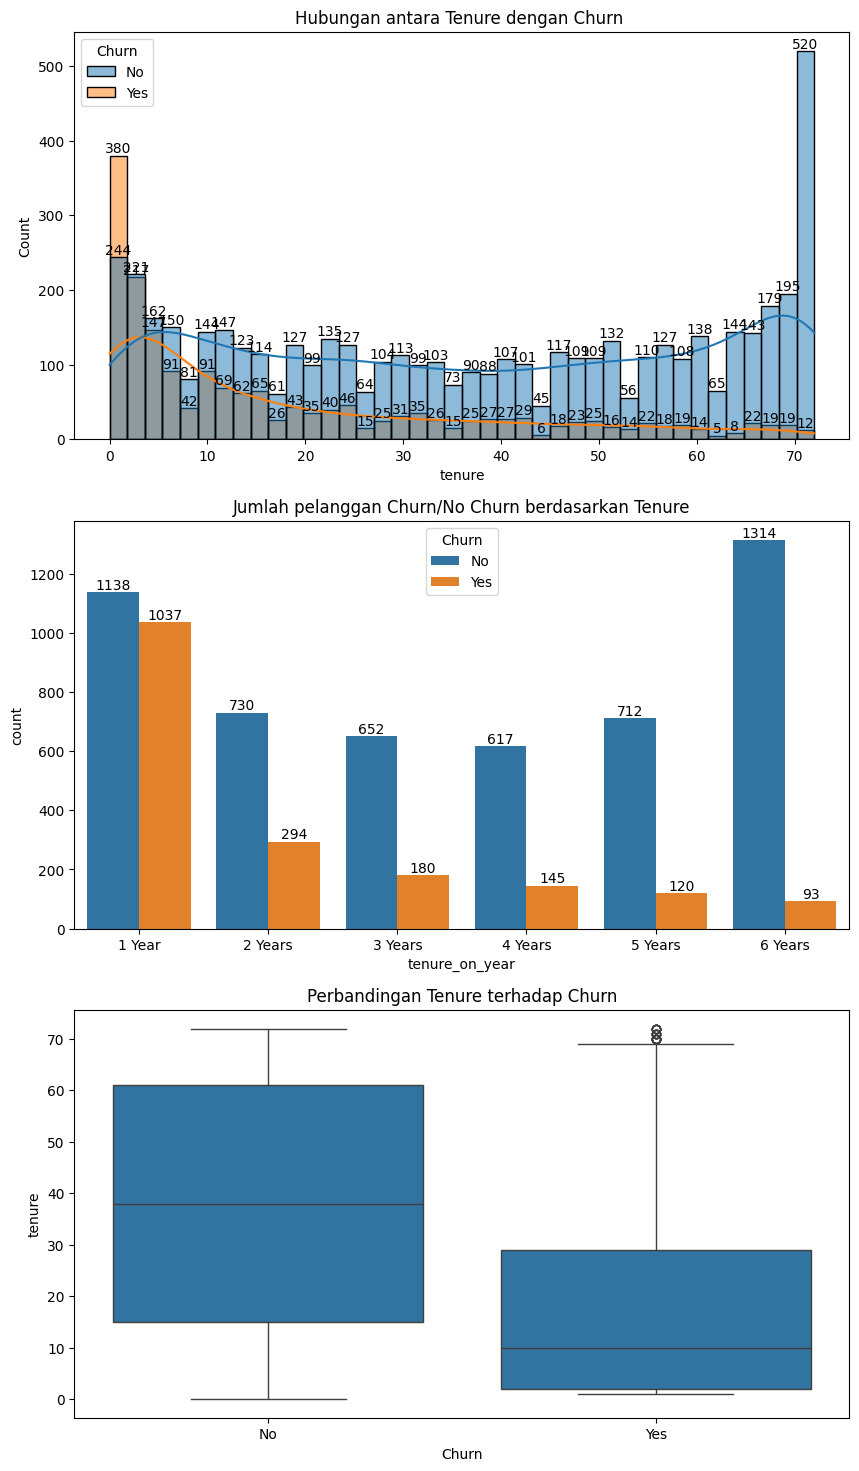

In [64]:
# hubungan tenure(lama berlangganan) dengan churn
fig, axes = plt.subplots(3,1, figsize=(10, 18))

# tenure vs churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=40, kde=True, ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Hubungan antara Tenure dengan Churn ')

# melihat jumlah banyaknya pelanggan churn atau tidak dalam tahunan
df['tenure_on_year'] = pd.cut(df['tenure'], bins=(0,12,24,36,48,60,72),
                           labels=['1 Year','2 Years','3 Years','4 Years','5 Years','6 Years'])
sns.countplot(data=df, x='tenure_on_year', hue='Churn',ax=axes[1])
for i in axes[1].containers:
    axes[1].bar_label(i)
axes[1].set_title('Jumlah pelanggan Churn/No Churn berdasarkan Tenure')

# hubungan tenure dengan chuen dalam bentuk boxplot=
sns.boxplot(data=df, x='Churn', y='tenure')
axes[2].set_title('Perbandingan Tenure terhadap Churn')

plt.show()

Visualisasi menunjukkan bahwa pelanggan dengan tenure rendah (awal berlangganan) memiliki jumlah churn yang jauh lebih tinggi dibandingkan pelanggan dengan tenure yang lebih lama. Hal ini terlihat baik dari distribusi maupun agregasi per tahun, di mana churn paling banyak terjadi pada tahun pertama dan terus menurun seiring bertambahnya lama berlangganan. Pola ini mengindikasikan bahwa pelanggan baru merupakan kelompok yang paling rentan untuk berhenti.

Boxplot juga memperkuat temuan tersebut, di mana median tenure pelanggan yang churn jauh lebih rendah dibandingkan yang tidak churn. Pelanggan yang tidak churn cenderung memiliki tenure yang lebih tinggi dan distribusi yang lebih luas, menunjukkan tingkat loyalitas yang lebih kuat. Dengan demikian, dapat disimpulkan bahwa tenure merupakan faktor penting dalam churn, di mana semakin lama pelanggan berlangganan, semakin kecil kemungkinan mereka untuk berhenti.

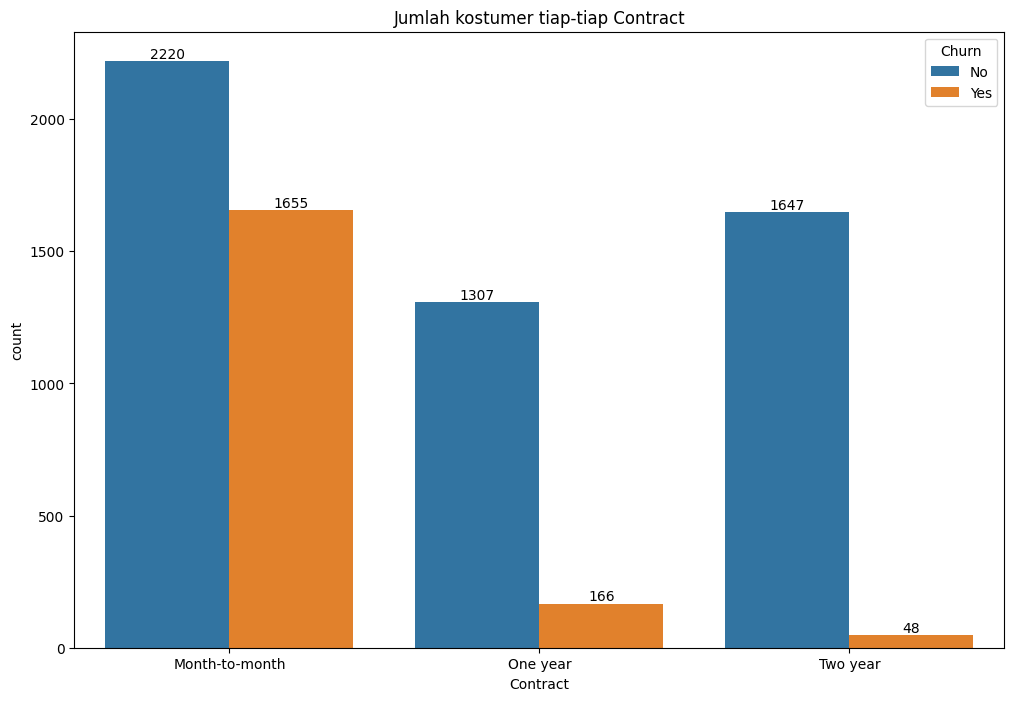

In [56]:
# Contrac dengan Churn
# biasana kalo contraknya dalam tahunan kemungkinan besar Churnnya kecil

plt.figure(figsize=(12,8))
ax=sns.countplot(data=df, x='Contract', hue='Churn')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Jumlah kostumer tiap-tiap Contra')
plt.show()

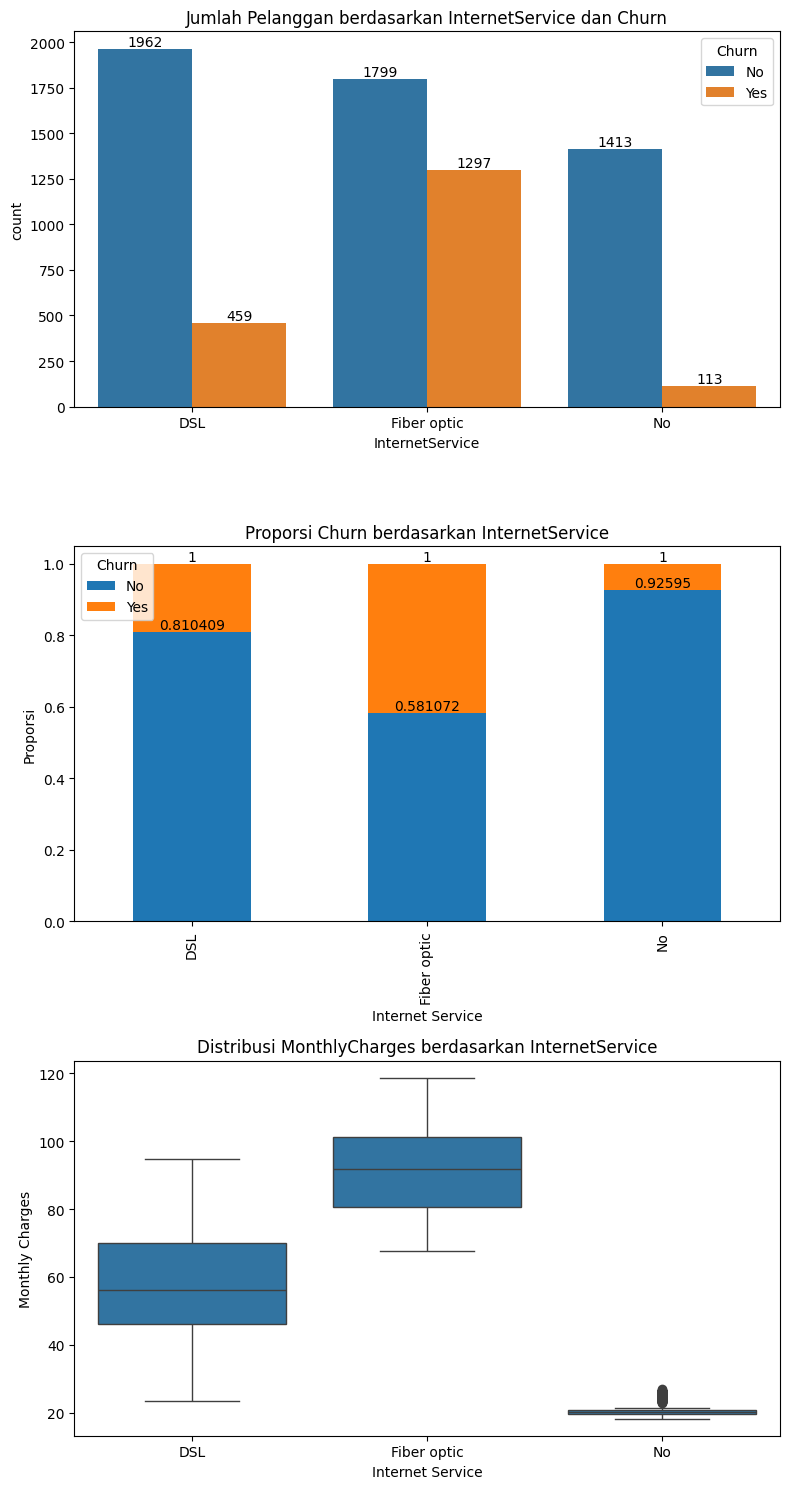

In [98]:
# Visualisasi InternetService

# countplot
fig, axes = plt.subplots(3,1, figsize=(8,15))
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Jumlah Pelanggan berdasarkan InternetService dan Churn')

# Proporsi Churn
ct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[1])
for i in axes[1].containers:
    axes[1].bar_label(i)
axes[1].set_title('Proporsi Churn berdasarkan InternetService')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Proporsi')

#  boxplot MonthlyCharges
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', ax=axes[2])
axes[2].set_title('Distribusi MonthlyCharges berdasarkan InternetService')
axes[2].set_xlabel('Internet Service')
axes[2].set_ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

Visualisasi menunjukkan bahwa pelanggan dengan layanan Fiber optic memiliki jumlah dan proporsi churn yang paling tinggi dibandingkan DSL dan tanpa internet. Meskipun jumlah pelanggan Fiber optic cukup besar, tingkat churn-nya juga signifikan, yang mengindikasikan bahwa segmen ini lebih rentan untuk berhenti berlangganan. Sebaliknya, pelanggan tanpa internet memiliki tingkat churn paling rendah, menunjukkan kecenderungan yang lebih stabil.

Dari sisi biaya, boxplot memperlihatkan bahwa Fiber optic memiliki MonthlyCharges paling tinggi, diikuti DSL, dan terendah pada pelanggan tanpa internet. Hal ini menguatkan indikasi bahwa biaya layanan yang lebih tinggi dapat menjadi faktor pendorong churn, terutama pada pengguna Fiber optic yang kemungkinan memiliki ekspektasi layanan lebih tinggi.

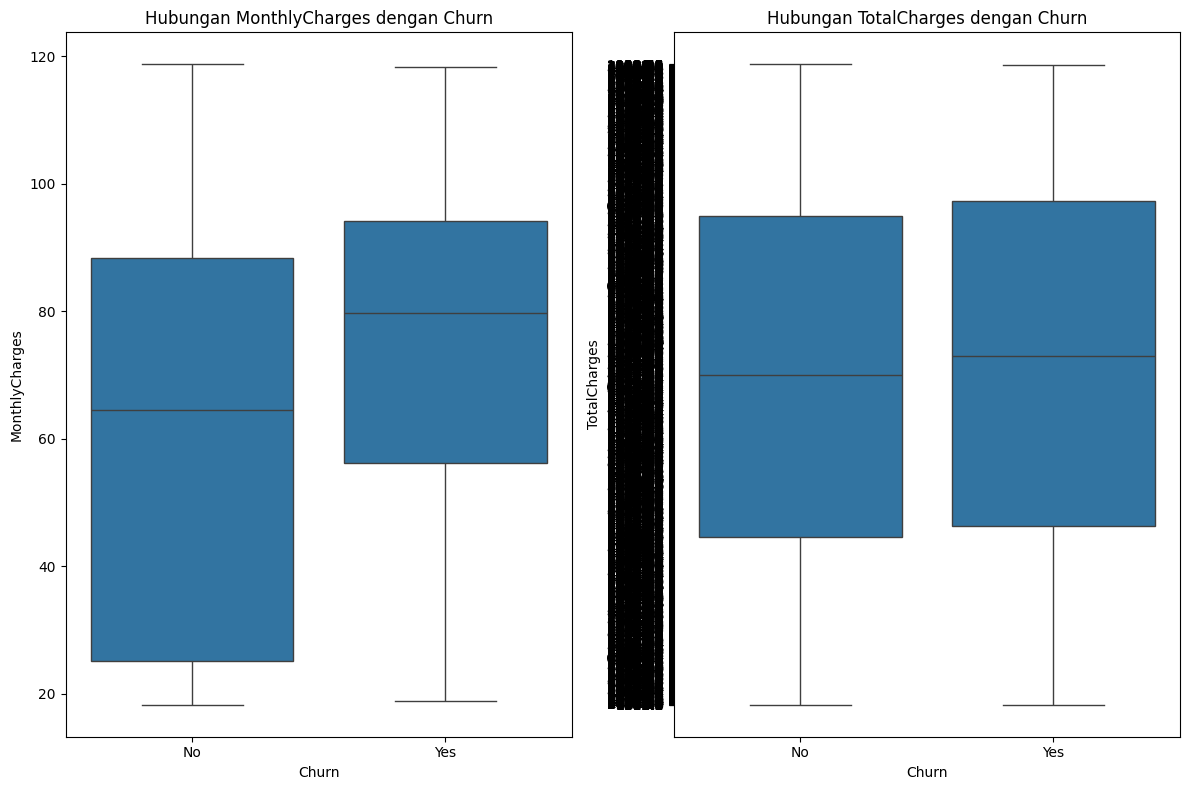

In [85]:
# MonthlyCharges dan TotalCharges dengan Churn 
fig, axes = plt.subplots(1,2, figsize=(12,8))

# MonthlyCharges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0])
axes[0].set_title('Hubungan MonthlyCharges dengan Churn')

# TotalCharges vs Churn
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1])
axes[1].set_title('Hubungan TotalCharges dengan Churn')

plt.tight_layout()
plt.show()

In [86]:
df['TotalCharges'].dtype

<StringDtype(storage='python', na_value=nan)>

Visualisasi menunjukkan bahwa pada MonthlyCharges, pelanggan yang melakukan churn memiliki median biaya yang lebih tinggi dibandingkan pelanggan yang tidak churn. Hal ini mengindikasikan bahwa biaya bulanan yang besar berpotensi meningkatkan kemungkinan pelanggan untuk berhenti berlangganan. Sementara itu, pada TotalCharges, pola yang terlihat belum memberikan perbedaan yang jelas antara kelompok churn dan non-churn, sehingga interpretasinya masih terbatas dan belum dapat dijadikan dasar kesimpulan yang kuat.

Perlu diperhatikan bahwa variabel TotalCharges masih bertipe object (string), sehingga visualisasi yang dihasilkan belum sepenuhnya merepresentasikan kondisi data yang sebenarnya, nanti akan dilakukan penyesuaian ketika preprocessing

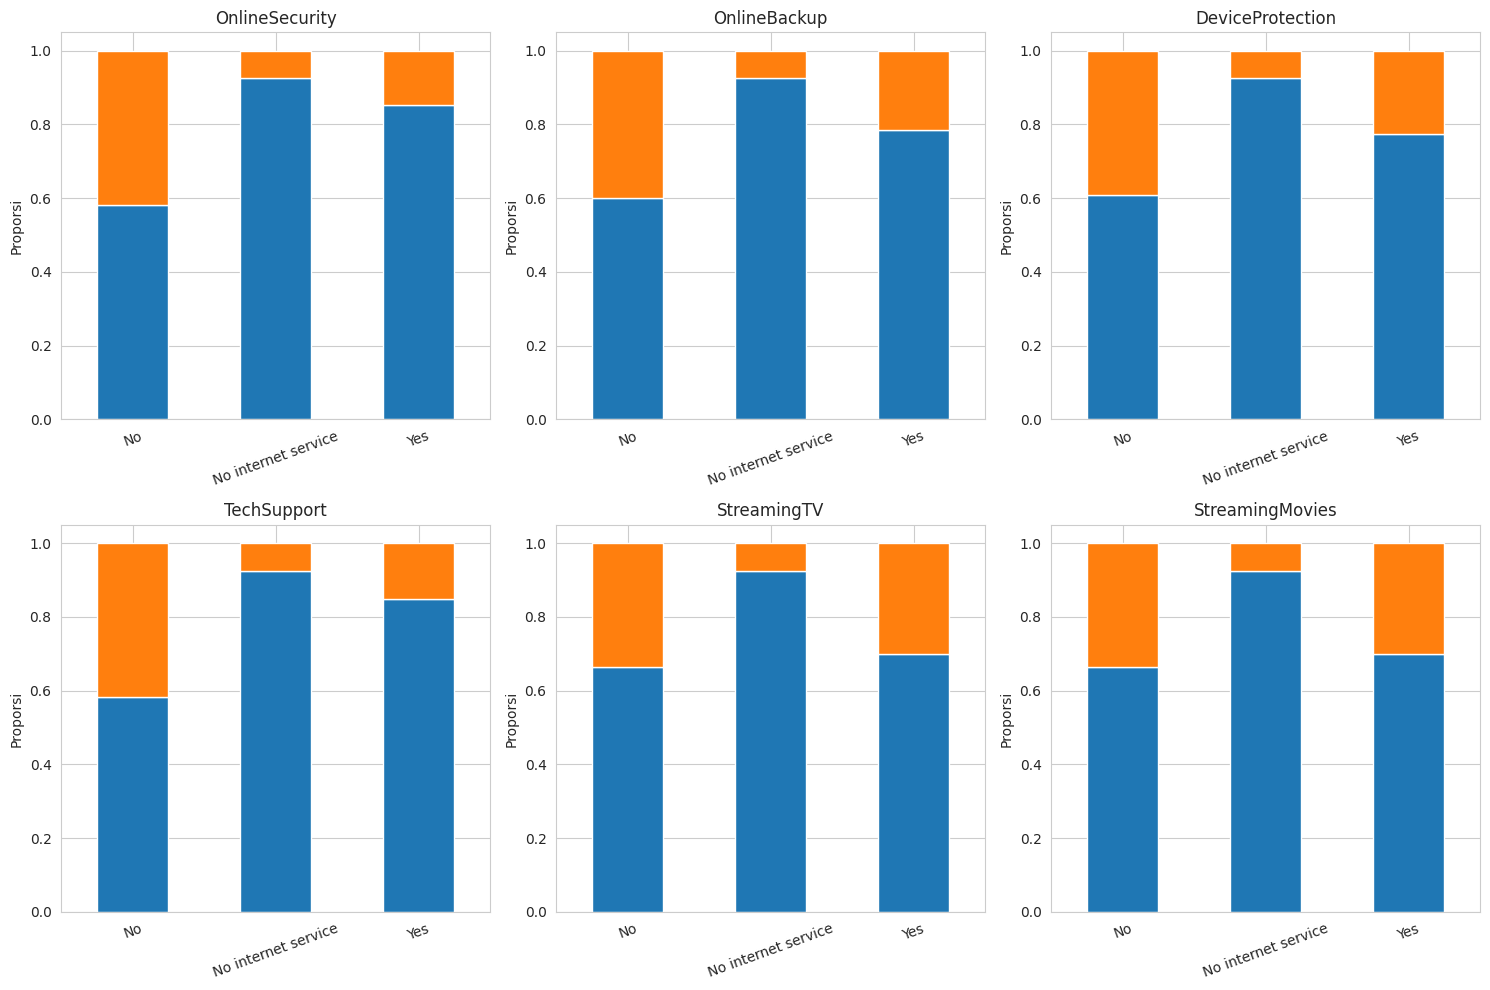

In [109]:
# Visualisasi semua jenis layanan yang ada
fig, axes = plt.subplots(2, 3, figsize=(15,10))
features = ['OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

# fitur total services
df['TotalServices'] = df[features].apply(lambda x: (x == 'Yes').sum(), axis=1)

# proporsi Churn untuk tiap fitur
for i, col in enumerate(features):
    row = i // 3
    col_idx = i % 3
    
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[row, col_idx], legend=False)
    
    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].set_ylabel('Proporsi')
    axes[row, col_idx].set_xlabel('')
    axes[row, col_idx].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

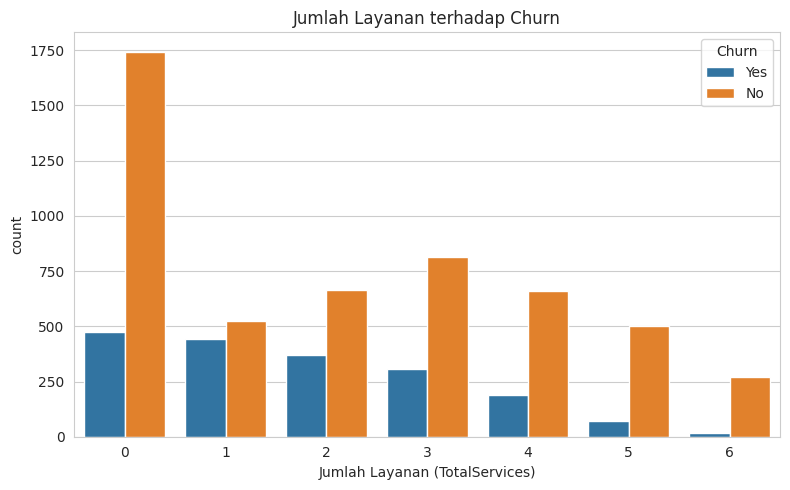

In [107]:
# Analisis Pengaruh Jumlah Layanan terhadap Churn
plt.figure(figsize=(8,5))

df['TotalServices'] = df[features].apply(lambda x: (x == 'Yes').sum(), axis=1)
sns.set_style("whitegrid")
sns.countplot(x='TotalServices', hue='Churn', data=df)

plt.title('Jumlah Layanan terhadap Churn')
plt.xlabel('Jumlah Layanan (TotalServices)')

plt.tight_layout()
plt.show()

# PREPROCESSING